In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 🌿 Plant Disease Classification - Data Preprocessing

## Objective

The objective of this notebook is to prepare the PlantVillage dataset for training.

### Tasks

- Load the dataset
- Create training and validation datasets
- Resize images
- Normalize pixel values
- Encode labels
- Apply data augmentation
- Handle class imbalance
- Build an efficient TensorFlow data pipeline

In [39]:
import random
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from torchvision import datasets
from torchvision import transforms

In [44]:
dataset_path = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

In [45]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8,1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

Why 224?

Although your images are 256×256, 224×224 is a common input size because many CNN architectures (including many pretrained models) expect it. It also reduces computation while preserving enough detail.

In [46]:
val_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [47]:
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

In [50]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

In [52]:
from copy import deepcopy

val_dataset.dataset = deepcopy(dataset)
val_dataset.dataset.transform = val_transform

In [55]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

happened automatically:

Labels created ✔
Images resized ✔
Data shuffled ✔
Batching ✔

In [56]:
class_names = dataset.classes

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


Class Weights

Remember the imbalance? (152 vs 3209 images) Before training, we have to compute class weights using the training labels so that errors on minority classes are penalized more. This is done just before model training to ensure the weights match the training split.

In [58]:
from sklearn.utils.class_weight import compute_class_weight

labels = dataset.targets

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    weights,
    dtype=torch.float
)

print(class_weights)

tensor([1.3800, 0.9309, 1.3759, 1.3759, 9.0518, 0.6469, 1.3759, 0.7207, 1.4452,
        0.7769, 0.8209, 0.9800, 0.4289, 3.6887, 0.8648])


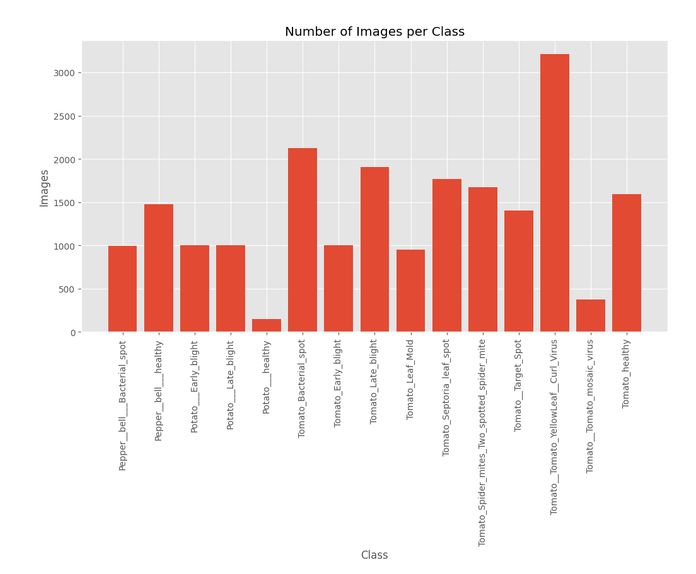

In [59]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [62]:
import torch.nn as nn

class PlantDiseaseCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # Block 2
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # Block 3
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            # Block 4
            nn.Conv2d(128,256,kernel_size=3,padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2,2)

        )

        self.classifier = nn.Sequential(

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),

            nn.Linear(256,256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256,num_classes)

        )

    def forward(self,x):

        x = self.features(x)

        x = self.classifier(x)

        return x
        

In [63]:
num_classes = len(class_names)

model = PlantDiseaseCNN(num_classes)

model = model.to(device)

In [64]:
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [65]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [66]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.2,
    patience=3
)

In [67]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        # Move to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [68]:
def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [69]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_accuracy = 0

In [70]:
EPOCHS = 15

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch [1/15] Train Loss: 1.3073 Train Acc: 57.58% Val Loss: 1.2264 Val Acc: 59.23%
Epoch [2/15] Train Loss: 0.7834 Train Acc: 73.74% Val Loss: 0.6508 Val Acc: 77.01%
Epoch [3/15] Train Loss: 0.5878 Train Acc: 80.04% Val Loss: 0.3979 Val Acc: 85.39%
Epoch [4/15] Train Loss: 0.5136 Train Acc: 82.51% Val Loss: 0.4170 Val Acc: 84.35%
Epoch [5/15] Train Loss: 0.4386 Train Acc: 85.05% Val Loss: 0.5541 Val Acc: 83.36%
Epoch [6/15] Train Loss: 0.3892 Train Acc: 86.82% Val Loss: 0.3315 Val Acc: 88.44%
Epoch [7/15] Train Loss: 0.3437 Train Acc: 88.29% Val Loss: 0.3509 Val Acc: 87.48%
Epoch [8/15] Train Loss: 0.3474 Train Acc: 88.24% Val Loss: 0.3249 Val Acc: 89.27%
Epoch [9/15] Train Loss: 0.2815 Train Acc: 90.18% Val Loss: 0.2862 Val Acc: 90.07%
Epoch [10/15] Train Loss: 0.2835 Train Acc: 90.45% Val Loss: 0.2100 Val Acc: 92.44%
Epoch [11/15] Train Loss: 0.2678 Train Acc: 90.99% Val Loss: 0.4484 Val Acc: 86.75%
Epoch [12/15] Train Loss: 0.2516 Train Acc: 91.30% Val Loss: 0.2091 Val Acc: 92.34%
E

In [71]:
torch.save(model.state_dict(), "final_model.pth")

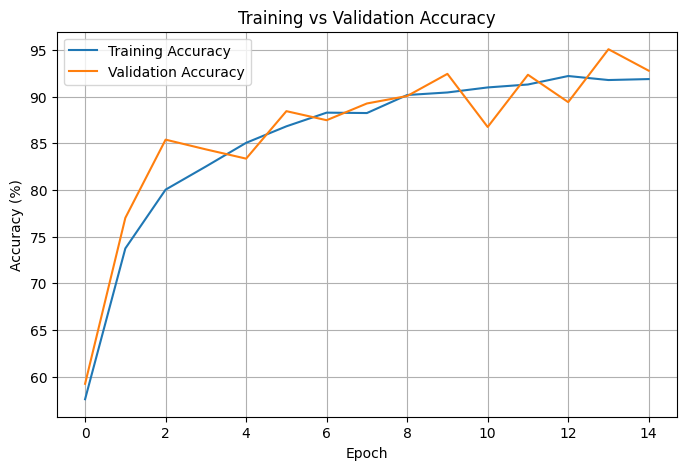

In [72]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

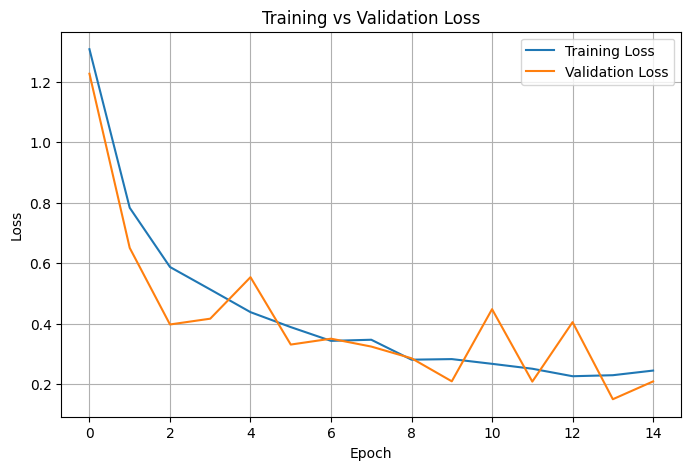

In [73]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()